In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeAthensV2

In [3]:
def create_circuit(choice):
    qc1 = QuantumCircuit(1)
    qc2 = QuantumCircuit(5)
    if choice == 1:
        qc1.x(0)
        return qc1
    
    elif choice == 2:
        qc1.x(0)
        qc1.h(0)
        return qc1
    
    elif choice == 3:
        qc1.x(0)
        qc1.barrier()
        qc1.h(0)
        return qc1
    
    elif choice == 4:
        qc2.cy(0,1)
        return qc2
         
    elif choice == 5:
        qc2.cx(0,1)
        return qc2
    
    else:
        qc2.h(0)
        qc2.h(3)
        qc2.cx(0,4)
        qc2.cswap(3,2,1)
        return qc2
    
    

In [4]:
def main():
    choice = int(input("Pick a gate :\n1. Simple X\n2. Add H\n3. H + Barrier\n4. Controlled-Y\n5. Non-conforming CX\n6. Multi-gate\n"))
    qc = create_circuit(choice)
    backend = FakeAthensV2()
    trans = transpile(qc,backend = backend)
    print(backend.num_qubits)
    
    print("Circuit:")
    display(qc.draw('mpl'))
    
    print("Transpiled Circuit:")
    display(trans.draw('mpl'))
    
    print("circuit depth:",qc.depth())
    print("circuit size",qc.size())
    print("transpiled circuit depth:",trans.depth())
    print("transpiled circuit size",trans.size())

5
Circuit:


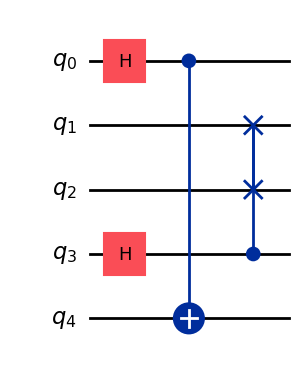

Transpiled Circuit:


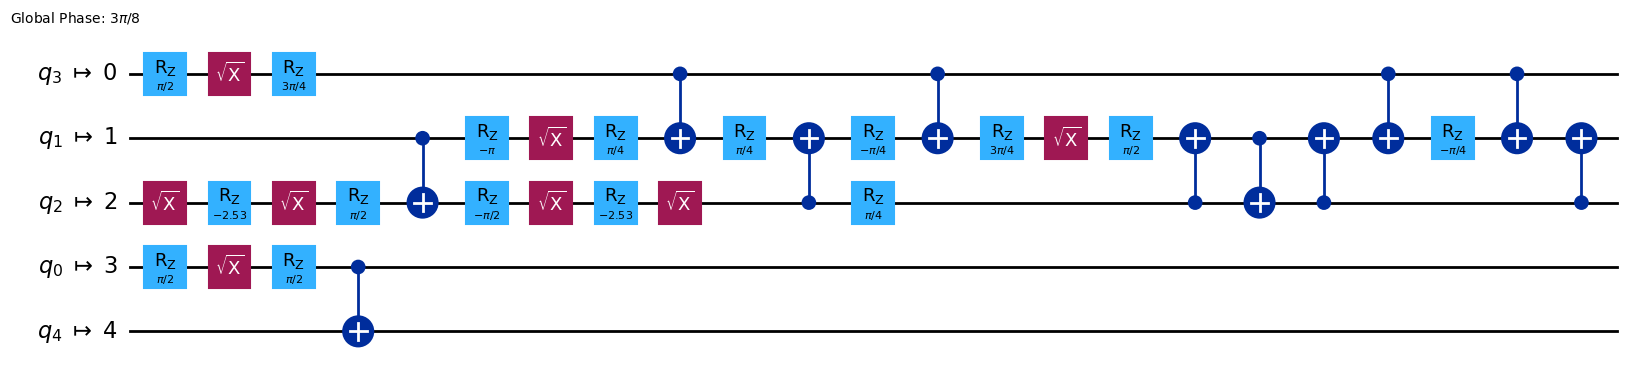

circuit depth: 2
circuit size 4
transpiled circuit depth: 23
transpiled circuit size 35


In [6]:
if __name__ == "__main__":
    main()
    